In [1]:
%load_ext autoreload
%autoreload 2

# import essential
import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))



# data organization

ephys sessions attached to /root/capsule/data
![{F610FAD2-377A-433B-B54D-BAB3032F8BD4}.png](attachment:{F610FAD2-377A-433B-B54D-BAB3032F8BD4}.png)

behavior nwb attached to /root/capsule/data/behavior_nwb
![{6A943A65-53FD-4292-9FBC-5A3E65621002}.png](attachment:{6A943A65-53FD-4292-9FBC-5A3E65621002}.png)

IBL_alignment attached to /root/capsule/data/IBL_alignment

![{F8FB3F64-5C81-4FF9-ABA8-B280A45BC44D}.png](attachment:{F8FB3F64-5C81-4FF9-ABA8-B280A45BC44D}.png)

In [25]:
# nwb handling
from nwb_utils import NWBUtils
from general_utils import find_ephys_sessions

sessions=find_ephys_sessions()
ephys_sessions=sessions[0]
session_name=ephys_sessions[18]
# read the ephys nwb
ephys_nwb=NWBUtils.read_ephys_nwb(session_name=session_name)

# read the behavior nwb
behavior_nwb=NWBUtils.read_behavior_nwb(session_name=session_name)

# combined behavior+ephys nwb
nwb_data,tag=NWBUtils.combine_nwb(session_name=session_name)


# read with full path
behavior_nwb=NWBUtils.read_behavior_nwb(nwb_full_path='/root/capsule/data/behavior_nwb/753126_2024-10-10_17-51-23.nwb')

nwb_data

Found ephys NWB: /root/capsule/data/ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33/nwb/ecephys_764790_2024-12-19_16-11-34_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33/nwb/ecephys_764790_2024-12-19_16-11-34_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Found ephys NWB: /root/capsule/data/ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33/nwb/ecephys_764790_2024-12-19_16-11-34_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33/nwb/ecephys_764790_2024-12-19_16-11-34_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Successfully read behavior NWB from: /root/c

/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753126_2024-10-10_17-51-23.nwb


Data type,float64
Shape,"(1,)"
Array size,8.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),8
Compressed size (bytes),8
Compression ratio,1.0
Data type,float64
Shape,"(1,)"


Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)


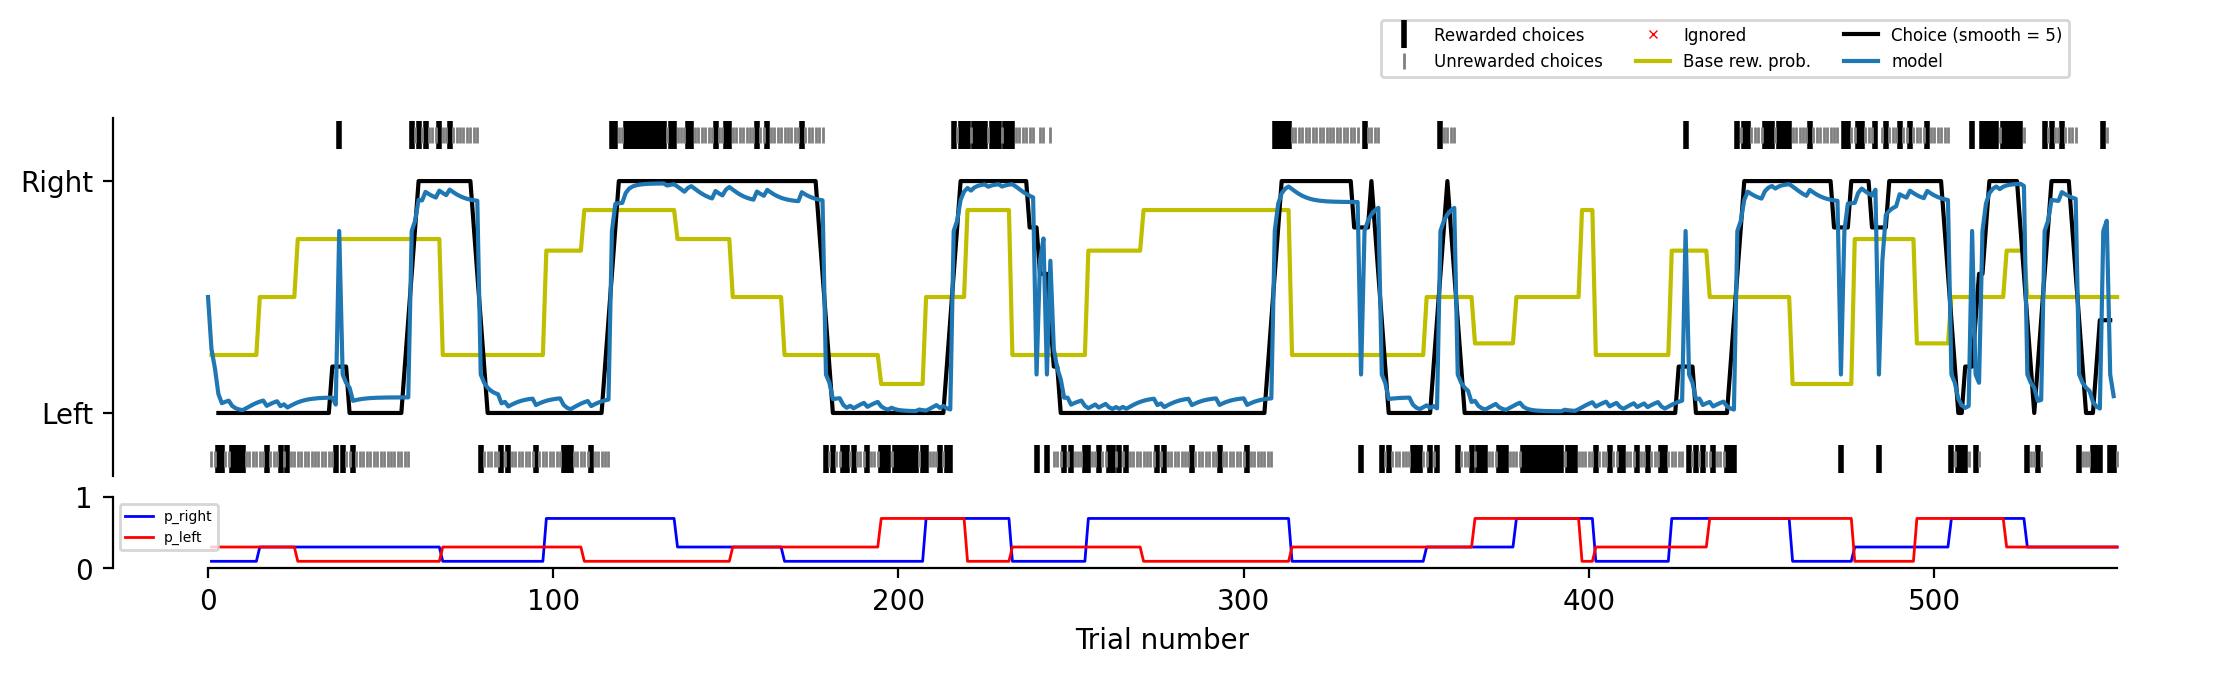

In [24]:
# behavior visualization
from general_visualization import plot_behavior_session

# behavior visualization
plot_behavior_session(nwb_data=nwb_data,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')


In [35]:
# extract the behavior events and latents
from behavior_utils import get_fitted_model_names, get_fitted_latent, extract_fitted_data
# get the fitted model names
print(get_fitted_model_names(session_name=session_name))
# get the fitted result
print(get_fitted_latent(session_name=session_name, model_alias='QLearning_L2F1_CK1_softmax'))
# extract the fitted latent 
extract_fitted_data(nwb_behavior_data=nwb_data,session_name=session_name,model_alias='QLearning_L2F1_CK1_softmax',latent_name='RPE')

['QLearning_L2F1_CK1_softmax', 'QLearning_L1F1_CK1_softmax', 'QLearning_L1F0_epsi', 'QLearning_L2F1_CKfull_softmax', 'QLearning_L2F1_softmax', 'WSLS', 'ForagingCompareThreshold', 'QLearning_L1F0_CKfull_softmax', 'QLearning_L1F1_CKfull_softmax']
{'params': {'learn_rate_rew': 0.5652476853989704, 'learn_rate_unrew': 0.052875333751444396, 'forget_rate_unchosen': 0.46714045192719167, 'choice_kernel_relative_weight': 0.16599089536791997, 'biasL': 0.1266821649206212, 'softmax_inverse_temperature': 3.3055097786974987, 'choice_kernel_step_size': 1}, 'fitted_latent_variables': {'q_value': [[0.0, 0.0, 0.0, 0.5652476853989704, 0.8109904249490474, 0.7681090355606408, 0.7274950139478719, 0.881527826573516, 0.9484939483870215, 0.9776076248452975, 0.9902648630720785, 0.937904277934814, 0.8883122762121033, 0.8413424681318831, 0.7968562043301458, 0.7547221665742802, 0.7148159801270518, 0.8760155872730098, 0.8296959707244818, 0.7858255193601962, 0.7442747327536237, 0.888822848162671, 0.8418260434201603, 

array([ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  4.34752315e-01,
       -8.10990425e-01, -7.68109036e-01,  2.72504986e-01,  1.18472173e-01,
        5.15060516e-02,  2.23923752e-02, -9.90264863e-01, -9.37904278e-01,
       -8.88312276e-01, -8.41342468e-01, -7.96856204e-01, -7.54722167e-01,
        2.85184020e-01, -8.76015587e-01, -8.29695971e-01, -7.85825519e-01,
        2.55725267e-01, -8.88822848e-01,  1.58173957e-01, -9.31233506e-01,
       -8.81994224e-01, -8.35358485e-01, -7.91188626e-01, -7.49354264e-01,
       -7.09731907e-01, -6.72204595e-01, -6.36661553e-01, -6.02997861e-01,
       -5.71114148e-01, -5.40916297e-01, -5.12315167e-01, -4.85226331e-01,
        5.40430173e-01,  1.00000000e+00,  5.92337544e-01, -7.42479882e-01,
       -7.03221010e-01,  3.33962036e-01, -8.54809232e-01, -8.09610909e-01,
       -7.66802462e-01, -7.26257526e-01, -6.87856416e-01, -6.51485779e-01,
       -6.17038251e-01, -5.84412147e-01, -5.53511160e-01, -5.24244073e-01,
       -4.96524492e-01, -

In [39]:
# generate the behavior summary
import os
from behavior_utils import generate_behavior_summary_combined
from general_utils import smart_read_csv



results_folder = '/root/capsule/scratch/behavior_summary'
os.makedirs(results_folder, exist_ok=True)
generate_behavior_summary_combined(
    session_names=[session_name],
    save_result=True,
    save_folder=results_folder,
)

df = smart_read_csv(f"/root/capsule/scratch/behavior_summary/behavior_summary-{session_name}.csv")



Found behavior NWB: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb


2026-02-26 00:15:01,234 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Can't extract right_choice_probability from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'choice_prob'
Can't extract right_choice_probability-1 from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'choice_prob'
Can't extract right_choice_probability+1 from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'choice_prob'
Can't extract left_choice_probability from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'choice_prob'
Can't extract left_choice_probability-1 from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'choice_prob'
Can't extract left_choice_probability+1 from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'choice_prob'
Can't extract QL from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'NoneType' object is not subscriptable
Can't extract QL-1 from ForagingCompareThreshold_L1_ResetF_StayBiasT_FixThrT0: 'NoneType' object is n

Found behavior NWB: /root/capsule/data/behavior_nwb/behavior_764769_2024-12-13_15-41-07.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/behavior_764769_2024-12-13_15-41-07.nwb
Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)
Can't extract None from None: If fitted_latent is not provided, session_name, model_alias, and latent_name are required
Plotting alias 'None' (latent: None)


2026-02-26 00:21:15,767 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...


Can't extract QL from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract QL-1 from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract QL+1 from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract QR from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract QR-1 from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract QR+1 from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract chosenQ from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract chosenQ-1 from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract chosenQ+1 from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract unchosenQ from ForagingCompareThreshold: 'NoneType' object is not subscriptable
Can't extract unchosenQ-1 from ForagingCompareThreshold: 'NoneType' object is not subscriptable


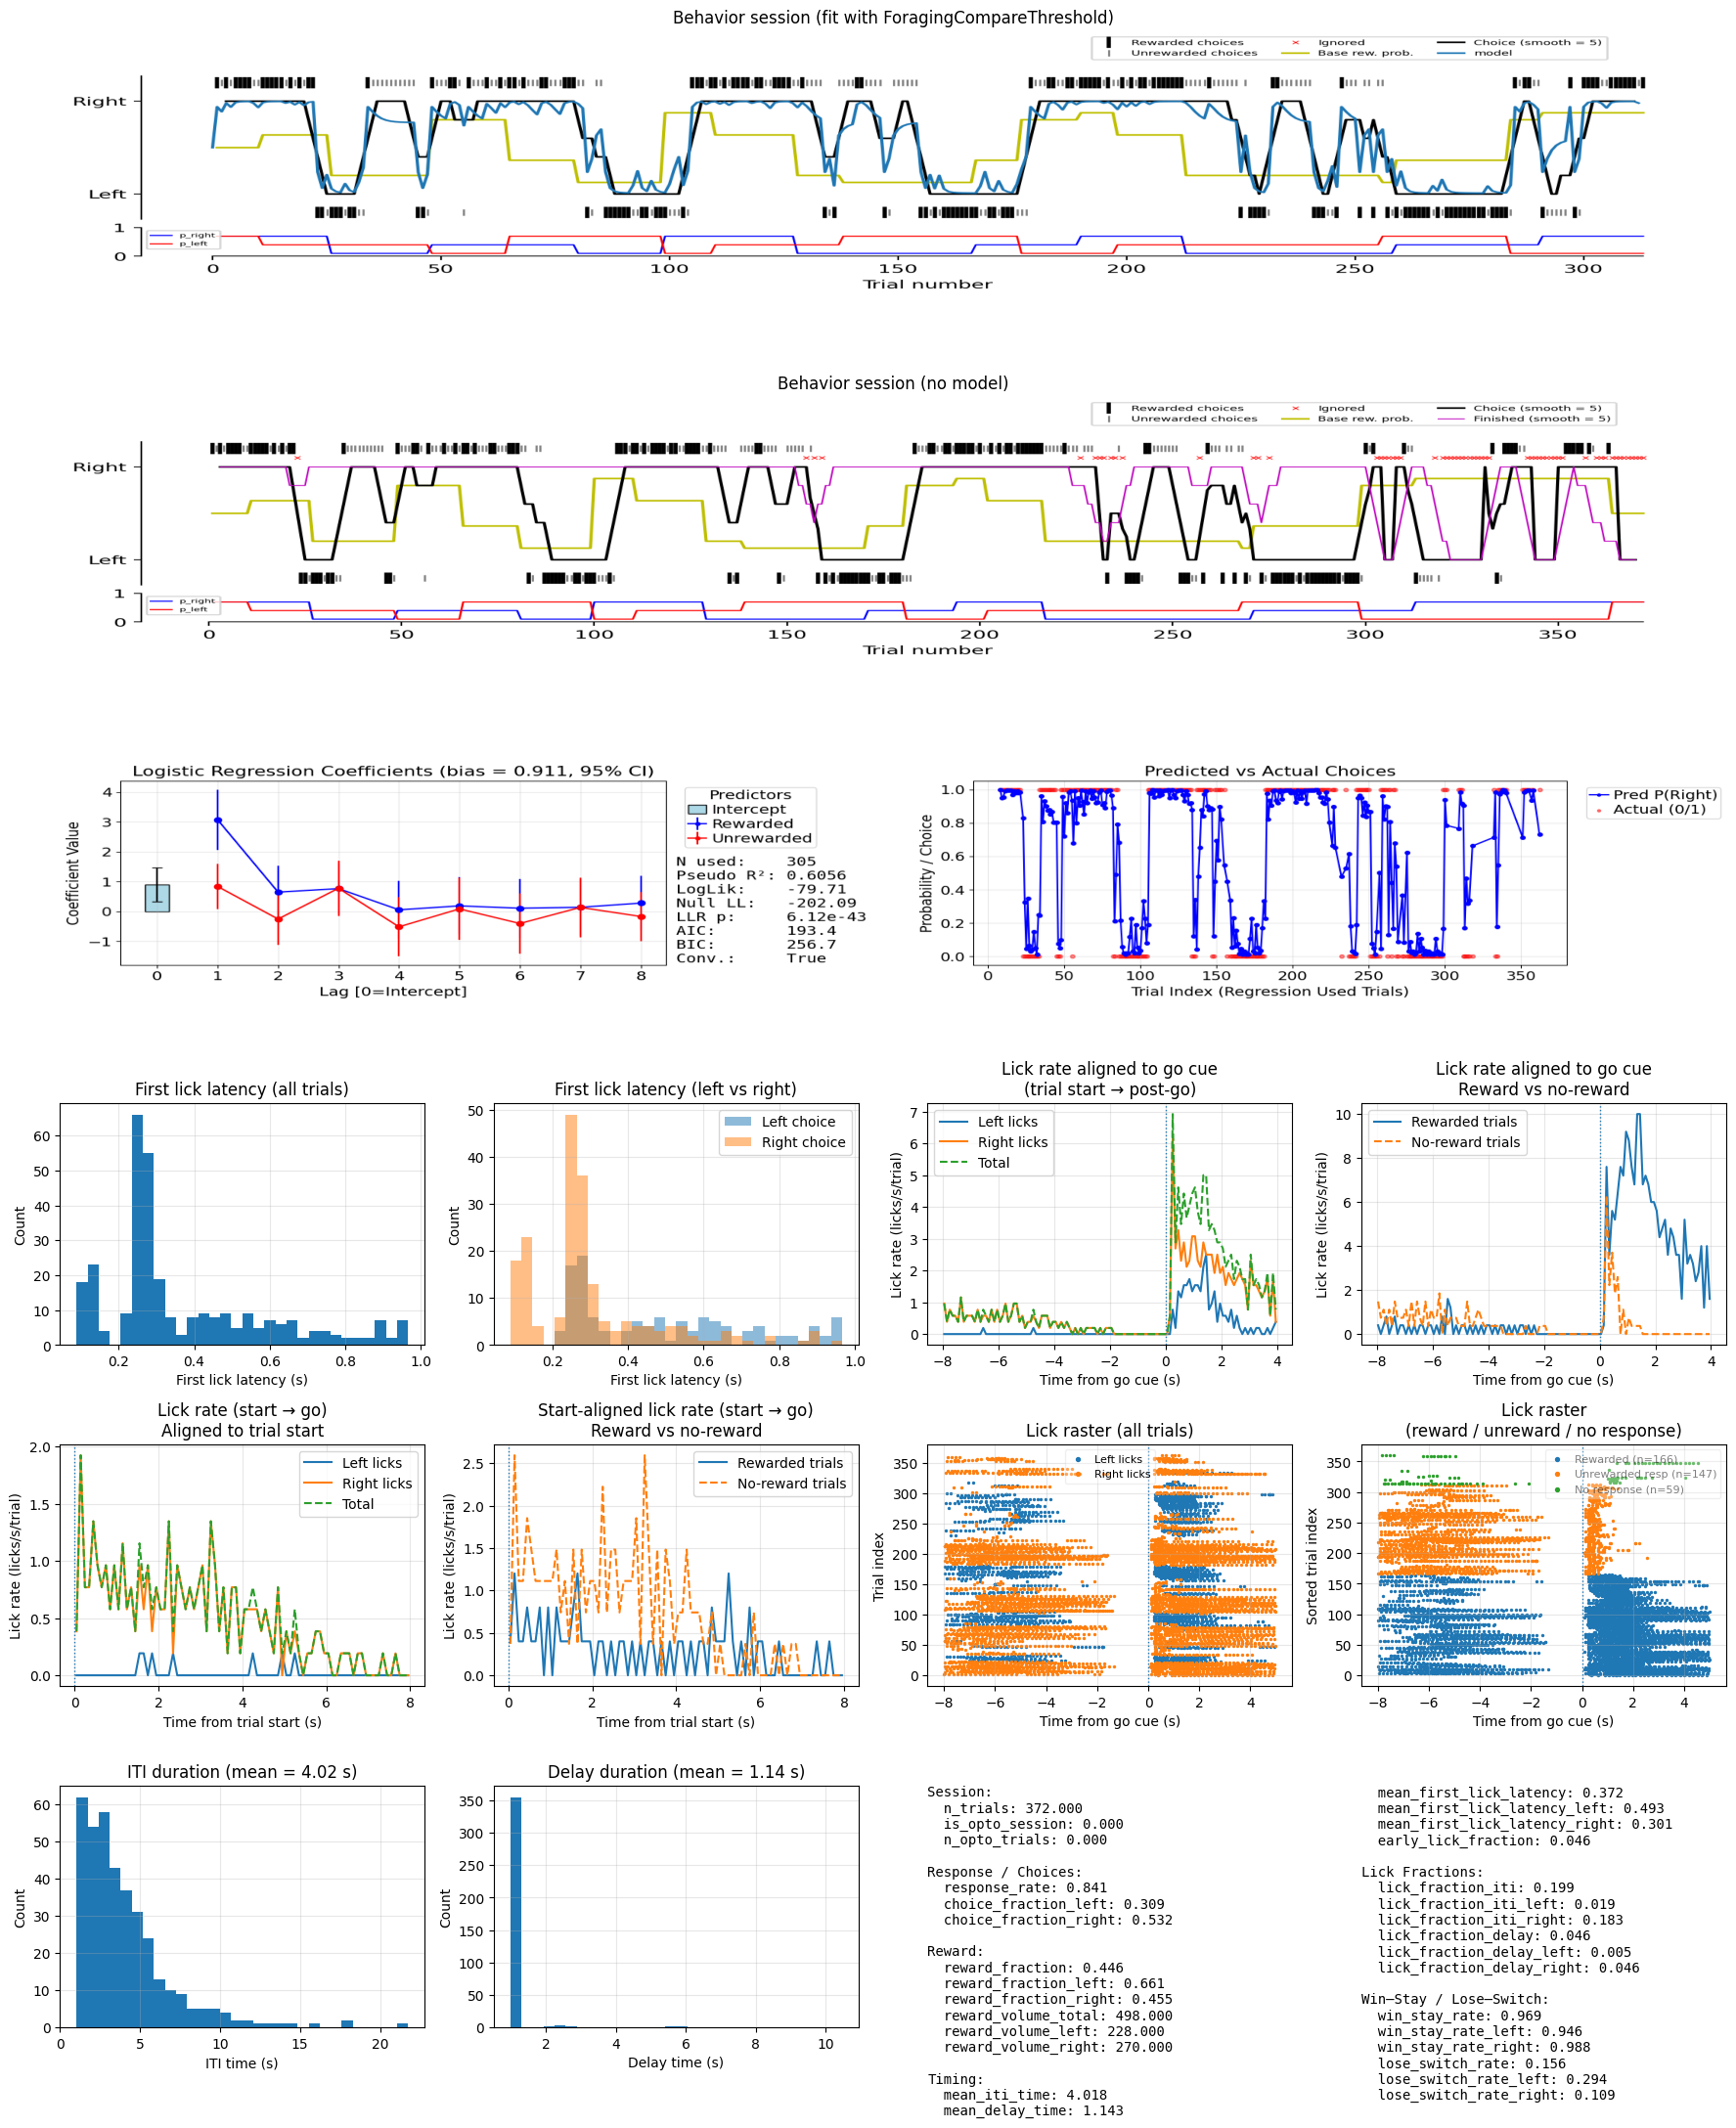

In [2]:
# behavior QC
from nwb_utils import NWBUtils
from general_utils import find_ephys_sessions
from behavior_qc_visualization import save_combined_behavior_and_qlearning_summary


# Get sessions
_, _, sessions = find_ephys_sessions()
# read behavior nwb from one example session
nwb_data = NWBUtils.read_behavior_nwb(session_name=sessions[10])

combined_fig, summary = save_combined_behavior_and_qlearning_summary(
    nwb_data,
    save_dir="/root/capsule/scratch/behavior_qc",
    save_basepath="qc_",
    formats=("pdf", "png", "eps"),
)



In [ ]:
# psth loading

In [ ]:
# plot the psth and raster

In [ ]:
# visualize the raster

In [ ]:
# performing the correlation

In [ ]:
# loading the correlation results and visualization

In [ ]:
# spatial visualization

In [ ]:
# tdr calculation

In [ ]:
# tdr visualization

In [ ]:
# coding direction